<a href="https://colab.research.google.com/github/LCaravaggio/Cosas_Sueltas/blob/main/Juego_de_la_Vida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regla 30

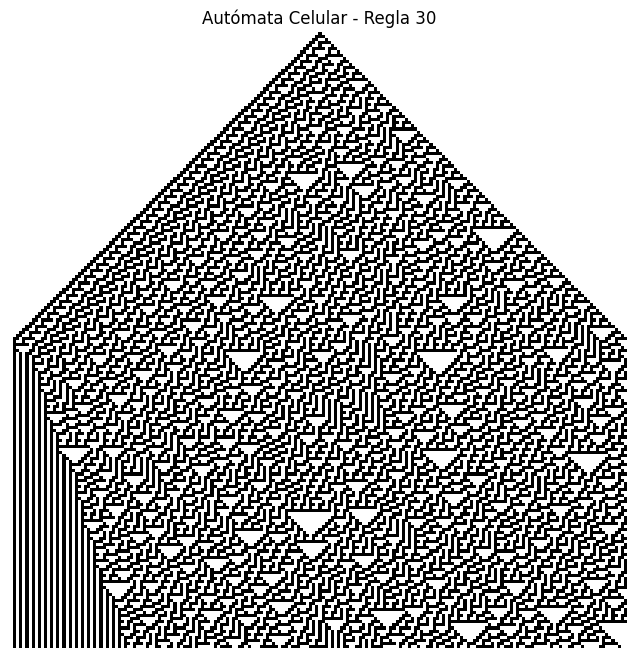

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
width = 201        # número de celdas
steps = 200        # número de iteraciones
rule_number = 30   # Regla 30

# Convertir número de regla a tabla binaria
rule_bin = np.array([int(x) for x in np.binary_repr(rule_number, width=8)])

# Inicializar grilla
grid = np.zeros((steps, width), dtype=int)
grid[0, width // 2] = 1  # una sola celda activa en el centro

# Evolución del autómata
for t in range(steps - 1):
    for i in range(1, width - 1):
        neighborhood = grid[t, i-1:i+2]
        idx = 7 - int("".join(map(str, neighborhood)), 2)
        grid[t + 1, i] = rule_bin[idx]

# Visualización
plt.figure(figsize=(8, 8))
plt.imshow(grid, cmap='binary')
plt.axis('off')
plt.title("Autómata Celular - Regla 30")
plt.show()

# Juego de la vida

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

N = 80
grid = np.zeros((N, N), dtype=int)

# Glider
# Glider
glider = np.array([
    [0,1,0],
    [0,0,1],
    [1,1,1]
])

# Bote (Boat)
boat = np.array([
    [1,1,0],
    [1,0,1],
    [0,1,0]
])

# Faro (Beacon)
beacon = np.array([
    [1,1,0,0],
    [1,1,0,0],
    [0,0,1,1],
    [0,0,1,1]
])

# Blinker (oscilador simple)
blinker = np.array([
    [1,1,1]
])

# Bloque (Block)
block = np.array([
    [1,1],
    [1,1]
])

# Nave Espacial Pesada
hwss = np.array([
    [0,0,1,1,1,1,0],
    [1,0,0,0,0,0,1],
    [0,0,0,0,0,0,1],
    [1,0,0,0,0,1,0],
    [0,0,1,0,1,0,0]
])

patterns = [
    (glider,  (5, 15)),
    (glider,  (15, 25)),
    (glider,  (25, 35)),
    (boat,    (20, 10)),
    (boat,    (5, 10)),
    (boat,    (20, 50)),
    (boat,    (50, 50)),
    (beacon,  (40, 30)),
    (blinker, (10, 50)),
    (blinker, (60, 70)),
    (block,   (50, 60)),
    (hwss, (20,10)),
    (hwss, (70,10))
]

for pattern, (x, y) in patterns:
    h, w = pattern.shape
    grid[x:x+h, y:y+w] = pattern

def update(frame):
    global grid
    new_grid = grid.copy()

    for i in range(N):
        for j in range(N):
            total = (
                grid[i, (j-1)%N] + grid[i, (j+1)%N] +
                grid[(i-1)%N, j] + grid[(i+1)%N, j] +
                grid[(i-1)%N, (j-1)%N] + grid[(i-1)%N, (j+1)%N] +
                grid[(i+1)%N, (j-1)%N] + grid[(i+1)%N, (j+1)%N]
            )

            if grid[i, j] == 1:
                if total < 2 or total > 3:
                    new_grid[i, j] = 0
            else:
                if total == 3:
                    new_grid[i, j] = 1

    grid[:] = new_grid
    img.set_array(grid)
    return img,

fig, ax = plt.subplots()
img = ax.imshow(grid, interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])

anim = animation.FuncAnimation(fig, update, frames=1500, interval=80)

plt.close(fig)
HTML(anim.to_jshtml())